<h1> Tutorial: Simple Metabolic Modeling in E. coli with CobraPy </h1>
<h3> Alexandros Papagiannakis, University of Groningen, 2014 </h3>

<h3> This guide will show you how to: 
<br>

<ol> 1. Install and import CobraPy. </ol>
<ol> 2. Define metabolites and reactions to build a metabolic network. </ol>
<ol> 3. Set up boundary conditions (uptake and secretion). </ol>
<ol> 4. Run a Flux Balance Analysis (FBA) to simulate cell growth (biomass). </ol>
<ol> 5. Try different carbon sources and simulate growth. </ol>
<ol> 6. Change the objective to simulate acetate production. </ol>
</h3>


<h3> Requirements: 
<br>

<ol> 1. Biochemistry knowledge: understanding central carbon metabolism. </ol>
<ol> 2. Object oriented programming: list and Numpy operations in Python. </ol>
</h3>

### Literature:
#### The lecture will be based on this [paper](https://www.nature.com/articles/nprot.2011.308): Please read before the first lecture!
### Derivables:
<h3>
<ol> <b> 1st session: </b> Theory and start building the model. </ol>
<ol> <b> 2nd session: </b> Finish the first version of the model and perform optimization for maximum growth. </ol>
<ol> <b> 3rd session: </b> Implement different carbon sources and exchange fluxes and quantify the growth rate. </ol>
<ol> <b> 4th session: </b> Try different objective functions, for the production of valuable metabolites. </ol>
<ol> <b> 5th session: </b> Flux variability analysis. </ol>
<ol> <b> 6th session: </b> Preparation of capstone project. Choose from: 
    <i>
    <ol> Improved biomass yields (e.g., in C3 plants)
    </ol>       
    <ol> Improved production of valuable metabolites (e.g., 3-Hydroxypropionate, EtOH)
    </ol>   
    <ol> Bioremediation (e.g., oil remediation)
    </ol>  
    </i>
</ol>

<ol> Final session: Presentations and feedback. </ol>
</h3>
<br>



<h1> Part 1: Installation and Setup </h1>

<ul> First, create a Python environment where you will install CobraPy. Always use this environment during the course. </ul> 
<ul>  Second, install CobraPy (Installation (in your terminal or command prompt) </ul> 
<ul> <code>pip install cobra</code></ul> 

In [15]:
import cobra
from cobra import Model, Reaction, Metabolite
from escher import Builder
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from cobra.flux_analysis import flux_variability_analysis
import seaborn as sns
from cobra.sampling import OptGPSampler  # if error, try ACHRSampler

<h1> Part 2: Model definition </h1>

<h3> Create an empty model for <i>Escherichia coli</i> </h3> 
<br> 
<h3> <b> Quiz </b> </h3>
<i> E. coli </i> does not contain membrane-bound comparments. How may compartments would you inluce in your model?


In [2]:
model = Model('ecoli_simple_core')

<h1> Part 3: Reaction definition </h1>

<h3> This part explains how to introduce a reaction in the <code>ecoli_simple_core</code> model. </h3>

<h3> <b> Quiz </b> </h3>
What does 'c' and 'e' stand for in the Reaction definition below?


In [3]:
# Reaction 1: Glucose uptake (GLCexch)
# glc__D_e -> g6p_c + adp_c
# Note: In E. coli, this is a phosphotransferase system, consuming PEP, but we'll simplify.
R1 = Reaction('GLCexch')
R1.name = 'Glucose transport'
R1.add_metabolites({
    Metabolite('glc_D_e', compartment='e'): -1.0,
    Metabolite('g6p_c', compartment='c'): 1.0
})
R1.lower_bound = 0 # Min glucose uptake at 10 mmol/gDW/hr. It does not take negatie values unless E. coli produces glucose.
R1.upper_bound = 10 # Max glucose uptake at 10 mmol/gDW/hr. You can try different glucose uptake rates.
model.add_reactions([R1]) # you can append the ractions list and include them at the end.

<h1> Part 4: Objective function definition </h1>

<h3> Here we we determine the objective function. </h3>
<h3> <b> Quiz </b> </h3>
Define the objective function value and link it to the metabolites in the core network. Use your biochemistry knowledge to link metabolites with building blocks and energy equivalents. You will need to gradually build these links as you complete the network.


```text
+------------------------------------------------+
|          1. DEFINING THE REACTION              |
|          (What you write in the code)          |
+------------------------------------------------+
|                                                |
|   Reaction: BIOMASS                            |
|                                                |
|   Metabolites & Coefficients:                  |
|     - amino_acid_c: -5.0   (Reactant)          |
|     - nucleotide_c: -2.0   (Reactant)          |
|     - lipid_c:      -1.0   (Reactant)          |
|     - atp_c:        -30.0  (Reactant)          |
|     - (biomass):     +1.0   (Product)          |
|                                                |
+------------------------------------------------+
                        |
                        | model.optimize()
                        v
+------------------------------------------------+
|          2. CALCULATING THE FLUX               |
|          (What the solver does)                |
+------------------------------------------------+
|                                                |
|   Finds the optimal FLUX (rate) for the        |
|   BIOMASS reaction.                            |
|                                                |
|   Result:                                      |
|     - Flux of BIOMASS reaction: +0.20          |
|       (A POSITIVE value, meaning               |
|        the reaction is happening!)             |
|                                                |
+------------------------------------------------+


<h1> Part 5: Reaction simplification </h1>

<h3> Here we provide an example where we simplify the TCA cycle. </h3>
<h3> <b> Quiz </b> </h3>
Apply the appropriate simplifications to the rest of the metabolic pathways (e.g., the pentose phosphate pathway) always keeping the objective function in mind.



## 1. Very Detailed Krebs Cycle (Step-by-Step)

This is the most granular view, representing the key enzymatic steps and nearly all major intermediates.

**Shows:** Individual intermediates like Citrate, Succinate, Fumarate, and Malate.
**Use Case:** Modeling specific biosynthetic pathways (e.g., heme synthesis from Succinyl-CoA).

```text
                                         (from Pyruvate)
                                              |
                                              v
      +---------------------------------> Acetyl-CoA
      |                                       |
      |                                       | [Citrate Synthase]
      |                                       v
      |         Oxaloacetate <-------------- Citrate ------------------------> To Fatty Acids
      |              ^                          |
      |              | [Malate Dehydrogenase]     | [Aconitase]
      |              | (-1 NADH)                  v
 To Aspartate <---- Malate                       Isocitrate
      ^              ^                          |
      |              | [Fumarase]               | [Isocitrate Dehydrogenase]
      |              |                          | (-1 NADH, -1 CO₂)
      |         Fumarate <----------------------+-------------> Alpha-ketoglutarate ----> To Glutamate
      |              ^                                                      |
      |              | [Succinate Dehydrogenase]                            | [AKG Dehydrogenase]
      |              | (-1 FADH₂)                                           | (-1 NADH, -1 CO₂)
      |              v                                                      v
      +-------- Succinate <----------------- Succinyl-CoA ------------> To Heme Synthesis
                                           (-1 ATP)
                                           [Succinyl-CoA Synthetase]

## 2. Detailed Krebs Cycle (Two-Part View)

This is a common simplification. It splits the TCA cycle into two halves. It exposes the two most important biosynthetic hubs (Alpha-ketoglutarate and Oxaloacetate) without the complexity of the full cycle.

**Shows**: The main biosynthetic branch points.


```text
                                     To Amino Acid Synthesis
                                                ^
                                                |                          (e.g., Glutamate)
                                                |
                                Acetyl-CoA ---> Alpha-ketoglutarate --------+
                                    ^           (produces 1 NADH, 1 CO₂)    |
                                    |                                       |
                                    | (Upper Half)                          | (Lower Half)
                                    |                                       |
                                Oxaloacetate <------------------------------+
                                    ^            (produces 2 NADH, 1 FADH₂, 1 ATP, 1 CO₂)
                                    |
                                    |
                                    +-----------------------------------> To Amino Acid Synthesis
                                                                        (e.g., Aspartate)

## 3. Simplified Krebs Cycle (Lumped View)

This is the most abstract view, treating the entire cycle as a net balance of energy and redox balance equivalents. It has limitations when it comes to the accurate definition of an objective function which incudes building blocks such as amino acids and lipids. 



```text

                  |                          |
   Acetyl-CoA ---->     Lumped Krebs Cycle     ----> 3 NADH
                  |                          |
                  |                          |----> 1 FADH₂
                  |     (Black Box View)     |
                  |                          |----> 1 ATP
                  |                          |
                  |                          |----> 2 CO₂
                  +--------------------------+

<h1> Part 6: The core <i> E. coli </i> model. </h1>

<h3> <b> Quiz </b> </h3>

Test the model and change the exchange fluxes to modify the growth rate: [visit this website](https://cobrapy.readthedocs.io/en/0.25.0/getting_started.html) to learn how to modify the reactions. 

In [4]:
import cobra
from cobra.io import load_model
model = load_model("textbook")
print('Number of reactions:', len(model.reactions))
print('NUmber of metabolites:', len(model.metabolites))
print('Number of genes:', len(model.genes))
rxn = model.reactions.get_by_id("Biomass_Ecoli_core")
for met, coeff in rxn.metabolites.items():
    print(f"{met.id:25s} {coeff}")
print(model.objective)

# objective reaction id(s)
print([r.id for r in model.reactions if r.objective_coefficient != 0])

# most common direct access
print(model.reactions.get_by_id("Biomass_Ecoli_core").reaction)

sol = model.optimize()
print("Status:", sol.status)
print("Growth rate (objective value):", sol.objective_value, "per hour")


Number of reactions: 95
NUmber of metabolites: 72
Number of genes: 137
3pg_c                     -1.496
accoa_c                   -3.7478
atp_c                     -59.81
e4p_c                     -0.361
f6p_c                     -0.0709
g3p_c                     -0.129
g6p_c                     -0.205
gln__L_c                  -0.2557
glu__L_c                  -4.9414
h2o_c                     -59.81
nad_c                     -3.547
nadph_c                   -13.0279
oaa_c                     -1.7867
pep_c                     -0.5191
pyr_c                     -2.8328
r5p_c                     -0.8977
adp_c                     59.81
akg_c                     4.1182
coa_c                     3.7478
h_c                       59.81
nadh_c                    3.547
nadp_c                    13.0279
pi_c                      59.81
Maximize
1.0*Biomass_Ecoli_core - 1.0*Biomass_Ecoli_core_reverse_2cdba
['Biomass_Ecoli_core']
1.496 3pg_c + 3.7478 accoa_c + 59.81 atp_c + 0.361 e4p_c + 0.0709 f6p

Test the model and change the exchange fluxes to modify the growth rate: [visit this website](https://cobrapy.readthedocs.io/en/0.25.0/getting_started.html) to learn how to modify the reactions. 

In [5]:
builder = Builder(map_name="e_coli_core.Core metabolism",
                  model=model,
                  reaction_data=sol.fluxes.to_dict())
builder

Builder(reaction_data={'ACALD': 0.0, 'ACALDt': 0.0, 'ACKr': 1.8850036560801405e-15, 'ACONTa': 6.00724957535033…

<h1> Part 7: Changing the glucose uptake rate. </h1>

<h3> <b> Quiz </b> </h3>

Test different glucose uptake rates and plot the correlation with the growth rate.

In [6]:
model = load_model("textbook")

# Find the glucose exchange reaction (usually this ID in the textbook model)
print(model.reactions.EX_glc__D_e)

# Increase glucose uptake by making the LOWER bound more negative
# (uptake is negative flux for exchange reactions)
model.reactions.EX_glc__D_e.lower_bound = -20  # e.g., from -10 to -20

# Re-optimize
sol = model.optimize()
print("Growth rate (objective value):", sol.objective_value, "per hour")


EX_glc__D_e: glc__D_e <=> 
Growth rate (objective value): 1.7905689707194767 per hour


<h1> Part 8: Changing the objective function. </h1>

<h3> <b> Quiz </b> </h3>

Test different objective functions and copmare the flux distributions. Draw biologicaly meaningful conclusions. An example is provided below.

In [7]:
model = load_model("textbook")

# Check the acetate exchange reaction ID (usually this)
print(model.reactions.EX_ac_e)

# Set objective to maximize acetate secretion
model.objective = "EX_ac_e"

sol = model.optimize()
print("Status:", sol.status)
print("Max acetate secretion flux:", sol.objective_value)
print("Acetate flux:", sol.fluxes["EX_ac_e"])

EX_ac_e: ac_e --> 
Status: optimal
Max acetate secretion flux: 20.000000000000007
Acetate flux: 20.000000000000007


In [8]:
builder = Builder(map_name="e_coli_core.Core metabolism",
                  model=model,
                  reaction_data=sol.fluxes.to_dict())
builder

Builder(reaction_data={'ACALD': 0.0, 'ACALDt': 0.0, 'ACKr': -20.000000000000007, 'ACONTa': 0.0, 'ACONTb': 0.0,…

<h1> Part 9: Flux variability analysis. </h1>

#### In the [https://pmc.ncbi.nlm.nih.gov/articles/PMC3751080/](https://pmc.ncbi.nlm.nih.gov/articles/PMC3751080/) paper read about flux variability analysis to understand why it is useful. 


<h3> <b> Quiz </b> </h3>
Define the objective function value and link it to the metabolites in the core network. Use your biochemistry knowledge to link metabolites with building blocks and energy equivalents. You will need to gradually build these links as you complete the network.

EX_ac_e: ac_e --> 
Status: optimal
Max acetate secretion flux: 20.000000000000007
Acetate flux: 20.000000000000007
             minimum       maximum
ACALD   3.702411e-15  0.000000e+00
ACALDt  3.171626e-15  0.000000e+00
ACKr   -2.000000e+01 -2.000000e+01
ACONTa  0.000000e+00 -3.702411e-15
ACONTb  0.000000e+00 -3.585187e-15
ACALD - acetaldehyde dehydrogenase (acetylating)
    acald_c + coa_c + nad_c <=> accoa_c + h_c + nadh_c
ACALDt - R acetaldehyde reversible - transport
    acald_e <=> acald_c
ACKr - acetate kinase
    ac_c + atp_c <=> actp_c + adp_c
ACONTa - aconitase (half-reaction A, Citrate hydro-lyase)
    cit_c <=> acon_C_c + h2o_c
ACONTb - aconitase (half-reaction B, Isocitrate hydro-lyase)
    acon_C_c + h2o_c <=> icit_c


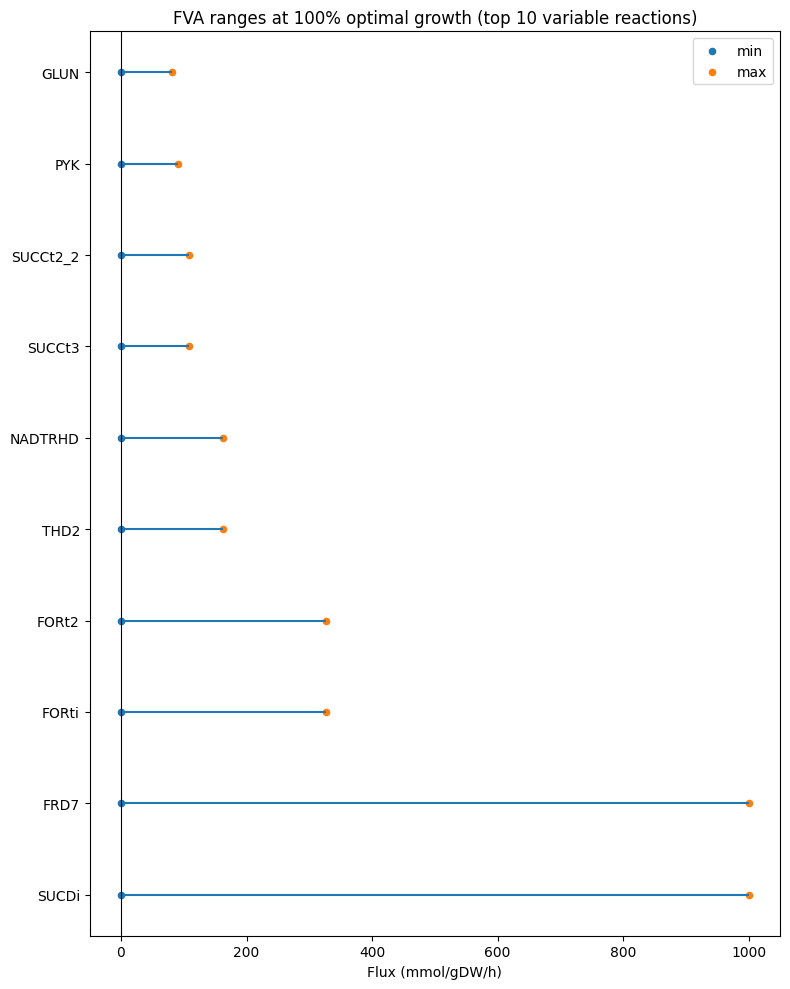

In [14]:
model = load_model("textbook")
print(model.reactions.EX_ac_e)
model.objective = "EX_ac_e"

sol = model.optimize()
print("Status:", sol.status)
print("Max acetate secretion flux:", sol.objective_value)
print("Acetate flux:", sol.fluxes["EX_ac_e"])

fva = flux_variability_analysis(
    model,
    reaction_list=[r.id for r in model.reactions],  # or a subset list
    fraction_of_optimum=1.0
)
print(fva.head())          # columns: minimum, maximum
# Save if you want:
# fva.to_csv("fva_results.csv")
rxn_ids = ["ACALD", "ACALDt", "ACKr", "ACONTa", "ACONTb"]
for rid in rxn_ids:
    r = model.reactions.get_by_id(rid)
    print(r.id, "-", r.name)
    print("   ", r.reaction)

fva = fva.copy()
fva["range"] = fva["maximum"] - fva["minimum"]
top = fva.sort_values("range", ascending=False).head(10)

# horizontal bars from minimum to maximum
plt.figure(figsize=(8, 10))
plt.hlines(y=top.index, xmin=top["minimum"], xmax=top["maximum"])
plt.scatter(top["minimum"], top.index, s=20, label="min")
plt.scatter(top["maximum"], top.index, s=20, label="max")
plt.axvline(0, color="k", linewidth=0.8)
plt.xlabel("Flux (mmol/gDW/h)")
plt.title("FVA ranges at 100% optimal growth (top 10 variable reactions)")
plt.legend()
plt.tight_layout()
plt.show()

<h3> <b> Quiz </b> </h3>
How do the variable fluxes correlate in the network and what do we learn from the correlations?

          G6PDH2r       PFK      GAPD       PDH        CS      ACKr
G6PDH2r  1.000000 -0.827820 -0.995752  0.173693 -0.969797  0.003010
PFK     -0.827820  1.000000  0.832287 -0.185823  0.826045  0.040908
GAPD    -0.995752  0.832287  1.000000 -0.167041  0.970632 -0.004361
PDH      0.173693 -0.185823 -0.167041  1.000000 -0.134937  0.043419
CS      -0.969797  0.826045  0.970632 -0.134937  1.000000  0.108031
ACKr     0.003010  0.040908 -0.004361  0.043419  0.108031  1.000000


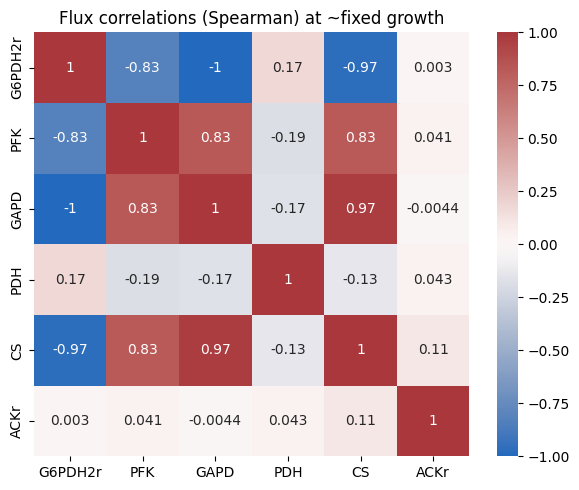

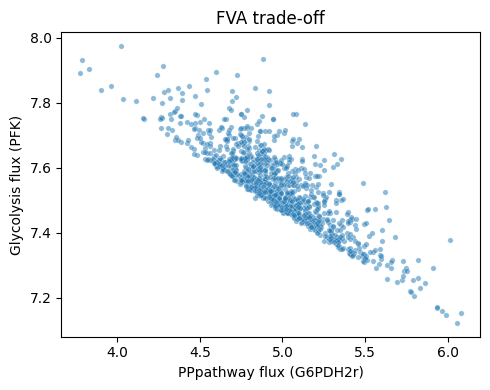

In [17]:
model = load_model("textbook")
model.objective = "Biomass_Ecoli_core"

# Fix growth at (e.g.) 99% of optimum to allow alternative optima
opt = model.slim_optimize()
model.reactions.Biomass_Ecoli_core.lower_bound = 0.99 * opt

# Sample flux space
sampler = OptGPSampler(model, processes=1, thinning=100)
samples = sampler.sample(1000)  # rows: samples, cols: reaction ids

# Example: compare PPP vs glycolysis (pick reaction IDs you care about)
# PPP proxy: G6PDH2r (often "G6PDH2r" in the textbook model)
# Glycolysis proxy: PFK or GAPD
rxns = ["G6PDH2r", "PFK", "GAPD", "PDH", "CS", "ACKr"]  # adjust to your IDs
df = samples[rxns]

# Correlation matrix
corr = df.corr(method="spearman")  # spearman is robust
print(corr)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="vlag", center=0, vmin=-1, vmax=1)
plt.title("Flux correlations (Spearman) at ~fixed growth")
plt.tight_layout()
plt.show()

# Scatter plot for a specific pair (PPP vs glycolysis)
plt.figure(figsize=(5,4))
sns.scatterplot(x=df["G6PDH2r"], y=df["PFK"], s=15, alpha=0.5)
plt.xlabel("PPpathway flux (G6PDH2r)")
plt.ylabel("Glycolysis flux (PFK)")
plt.title("FVA trade-off")
plt.tight_layout()
plt.show()